# Arabalar Veri Seti

In [ ]:
# 1 - DATA MANIPULATION
import pandas as pd
import numpy as np

# 2 - DATA VISUALISATION
import matplotlib.pyplot as plt
import seaborn as sns

# 3 - STATISTICS
from statsmodels.graphics.gofplots import qqplot

# 4 - MACHINE LEARNING

## 4.1 - Preprocessing

### 4.1.1 - Scalers
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler

### 4.1.2 - Encoders
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder

### 4.1.3 - Crossvalidation, Training, Model
from sklearn.model_selection import cross_validate
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

### 4.1.4 - Evaluation
from sklearn.metrics import confusion_matrix
from sklearn.metrics  import ConfusionMatrixDisplay

# 🚗 Arabalar veri seti

👇 [***ML_Cars_Recap_dataset.csv veri setini***](https://wagon-public-datasets.s3.amazonaws.com/Machine%20Learning%20Datasets/ML_Cars_Recap_dataset.csv) içe aktarmak için aşağıdaki kodu çalıştırın - _bu versiyon challenge 3'teki versiyondan biraz farklıdır._

In [ ]:
aws_url = "https://d32aokrjazspmn.cloudfront.net/materials/ML_Cars_Recap_dataset.csv"
cars = pd.read_csv(aws_url)
cars.head()


,aspiration,carwidth,curbweight,enginetype,cylindernumber,stroke,peakrpm,price
0,std,64.10000,2548.0,dohc,four,2.68,5000.0,expensive
1,std,64.10000,2548.0,dohc,four,2.68,5000.0,expensive
2,std,65.50000,2823.0,ohcv,six,3.47,5000.0,expensive
3,std,65.88794,2337.0,ohc,four,3.40,5500.0,expensive
4,std,66.40000,2824.0,ohc,five,3.40,5500.0,expensive


In [ ]:
cars.shape # 205 cars x 8 features

(205, 8)

ℹ️ Veri setinin açıklaması [burada](https://wagon-public-datasets.s3.amazonaws.com/Machine%20Learning%20Datasets/ML_Cars_dataset_description.txt) mevcuttur.

❓ **Soru (Bilgi)** ❓ Veri setiniz hakkında temel bilgileri toplayın.

In [ ]:
cars.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   aspiration      205 non-null    object 
 1   carwidth        205 non-null    float64
 2   curbweight      205 non-null    float64
 3   enginetype      205 non-null    object 
 4   cylindernumber  205 non-null    object 
 5   stroke          205 non-null    float64
 6   peakrpm         205 non-null    float64
 7   price           205 non-null    object 
dtypes: float64(4), object(4)
memory usage: 12.9+ KB


# (1) 🛠 Veri hazırlama

## (1.0) Ön gereksinimler

❓ **Soru (Potansiyel anomaliler)** ❓ 

- Veri tiplerinden dolayı değiştirilmesi gereken sütunlar var mı? 
    - Lütfen gerekli işlemleri yapın.

In [ ]:
# --->  `cylindernumber` should be integers, not objects...

cars['cylindernumber'].value_counts() # value_counts rank by descending order
                                      # the different unique values of a Pandas Series    

cylindernumber
four      159
six        24
five       11
eight       5
two         4
three       1
twelve      1
Name: count, dtype: int64

In [ ]:
# Let's convert the numbers to proper numbers

cars['cylindernumber'] = cars['cylindernumber'].map({"four":4,
                                                    "six":6,
                                                    "five":5,
                                                    "eight":8,
                                                    "two":2,
                                                    "three":3,
                                                    "twelve":12})

cars['cylindernumber'].value_counts()

cylindernumber
4     159
6      24
5      11
8       5
2       4
3       1
12      1
Name: count, dtype: int64

## (1.1) Yinelemeler

❓ **Soru (Yinelenen satırlar)** ❓ 

Arabalar veri setinin sahip olduğu yinelenen satır sayısını hesaplayın.

In [ ]:
cars.duplicated() # duplicated returns true if a row is a duplicated row of a previous one

0      False
1       True
2      False
3      False
4      False
       ...  
200    False
201    False
202    False
203    False
204    False
Length: 205, dtype: bool

In [ ]:
number_of_duplicated_rows = cars.duplicated().sum() # Check the number of duplicated rows
number_of_duplicated_rows

14

❓ **Soru (Yinelemeleri kaldır)** ❓

In [ ]:
cars = cars.drop_duplicates().reset_index(drop=True) # no need to remember the previous index
cars

,aspiration,carwidth,curbweight,enginetype,cylindernumber,stroke,peakrpm,price
0,std,64.10000,2548.0,dohc,4,2.68,5000.0,expensive
1,std,65.50000,2823.0,ohcv,6,3.47,5000.0,expensive
2,std,65.88794,2337.0,ohc,4,3.40,5500.0,expensive
3,std,66.40000,2824.0,ohc,5,3.40,5500.0,expensive
4,std,66.30000,2507.0,ohc,5,3.40,5500.0,expensive
...,...,...,...,...,...,...,...,...
186,std,68.90000,2952.0,ohc,4,3.15,5400.0,expensive
187,turbo,68.80000,3049.0,ohc,4,3.15,5300.0,expensive
188,std,68.90000,3012.0,ohcv,6,2.87,5500.0,expensive
189,turbo,68.90000,3217.0,ohc,6,3.40,4800.0,expensive


## (1.2) Eksik veri

❓ **Soru (`NaN`)** ❓ 

Her özellik için `NaN` yüzdesi nedir?

In [ ]:
cars.isnull().sum().sort_values(ascending=False) / len(cars) #NaN percentage for each column

aspiration        0.0
carwidth          0.0
curbweight        0.0
enginetype        0.0
cylindernumber    0.0
stroke            0.0
peakrpm           0.0
price             0.0
dtype: float64

<details>
    <summary><i>Cevap</i></summary>
    
😇 Bu bir mucize ama burada eksik değerlerimiz yok. Bu not defterinin bir sonraki bölümüne geçebilirsiniz :) 
    
</details>

## (1.3) Özellikleri $X$ ve hedefi $y$ tanımlama

❓ **Soru** ❓

- Bu veri setinin özelliklerini $X$ değişkeninde saklayın
- Hedefi $y$ değişkeninde saklayın.

In [ ]:
print(f"The columns of the dataset are {cars.columns}")

The columns of the dataset are Index(['aspiration', 'carwidth', 'curbweight', 'enginetype', 'cylindernumber',
       'stroke', 'peakrpm', 'price'],
      dtype='object')


In [ ]:
# DEFINING THE TARGET
y = cars['price'] # the price here is either expensive or cheap

# DEFINING THE FEATURES
X = cars.drop(columns=['price'])

❓ **Soru (Hedefe hızlı bakış)** ❓ "Ucuz" arabalara karşı "pahalı" arabaların oranı nedir?

In [ ]:
round(y.value_counts(normalize=True), 2)

price
expensive    0.61
cheap        0.39
Name: proportion, dtype: float64

## (1.4) Sayısal özellikleri ölçekleme

❓ **Soru (sayısal sütunlara hızlı bakış)** ❓

- Tüm sayısal sütunların boxplot'larını tek satır kodla gösterin
- Histogramları kullanarak dağılımları için aynısını yapın

<AxesSubplot:ylabel='Frequency'>

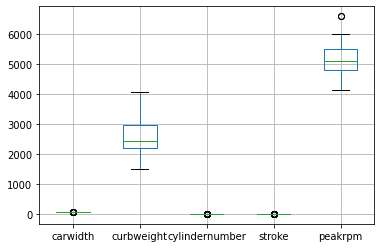

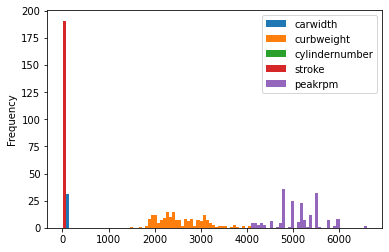

In [ ]:
cars.boxplot() # Graph boxplot of dataset
cars.plot.hist(bins=100) # Graph histograms of dataset

❓ **Soru (Sayısal sütunlara odaklan)** ❓

Arabalar veri setinin sayısal sütunlarını `cars_num` içinde saklayın.

In [ ]:
###########################
# Manual solution         # - not very smart
###########################

# num_features = ["carwidth", "curbweight", "cylindernumber", "stroke", "peakrpm"]
# cars_num = X[num_features]

# That is one way to select the numerical features...
# But not very smart...

###########################
# Elegant solution        # - much better
###########################

cars_num = X.select_dtypes(exclude=['object']) # selecting only the numerical features
cars_num

,carwidth,curbweight,cylindernumber,stroke,peakrpm
0,64.10000,2548.0,4,2.68,5000.0
1,65.50000,2823.0,6,3.47,5000.0
2,65.88794,2337.0,4,3.40,5500.0
3,66.40000,2824.0,5,3.40,5500.0
4,66.30000,2507.0,5,3.40,5500.0
...,...,...,...,...,...
186,68.90000,2952.0,4,3.15,5400.0
187,68.80000,3049.0,4,3.15,5300.0
188,68.90000,3012.0,6,2.87,5500.0
189,68.90000,3217.0,6,3.40,4800.0


❓ **Soru (Robust Scaler)** ❓

👨🏻‍🏫 Tüm sayısal özellikleri Robust Scaling ile ölçeklemek hızlı ve etkili bir ölçekleme yöntemidir.

In [ ]:
# Instantiating a RobustScaler
robust_scaler = RobustScaler().set_output(transform='pandas')

# Scaling the features and storing them
cars_num_scaled = robust_scaler.fit_transform(cars_num)

# Showing the scaled features
cars_num_scaled

,carwidth,curbweight,cylindernumber,stroke,peakrpm
0,-0.555556,0.135659,0.0,-2.033333,-0.142857
1,-0.037037,0.490956,2.0,0.600000,-0.142857
2,0.106644,-0.136951,0.0,0.366667,0.571429
3,0.296296,0.492248,1.0,0.366667,0.571429
4,0.259259,0.082687,1.0,0.366667,0.571429
...,...,...,...,...,...
186,1.222222,0.657623,0.0,-0.466667,0.428571
187,1.185185,0.782946,0.0,-0.466667,0.285714
188,1.222222,0.735142,2.0,-1.400000,0.571429
189,1.222222,1.000000,2.0,0.366667,-0.428571


## (1.5) Kategorik özellikleri kodlama

❓ **Soru (Kategorik sütunlara odaklan)** ❓

Arabalar veri setinin kategorik sütunlarını `cars_categorical` içinde saklayın.

In [ ]:
# Manual solution --> not very smart

# categorical_features = ["aspiration", "enginetype"]
# cars_categorical = X[categorical_features]

# Elegant solution --> much better
cars_categorical = X.select_dtypes(include=['object']) # selecting only the categorical features
cars_categorical

,aspiration,enginetype
0,std,dohc
1,std,ohcv
2,std,ohc
3,std,ohc
4,std,ohc
...,...,...
186,std,ohc
187,turbo,ohc
188,std,ohcv
189,turbo,ohc


❓ **Soru: Kategorik özellikleri kodlarsak beklenen sütun sayısı nedir?** ❓

In [ ]:
cars_categorical["aspiration"].value_counts()

aspiration
std      156
turbo     35
Name: count, dtype: int64

👉 `aspiration` bir ikili özelliktir, bu nedenle onu kodlamak için sadece 1 sütun vektörüne ihtiyacımız olacak.

In [ ]:
round(cars_categorical["enginetype"].value_counts() / len(cars_categorical), 2)

enginetype
ohc      0.72
ohcf     0.07
ohcv     0.07
dohc     0.06
l        0.06
rotor    0.02
dohcv    0.01
Name: count, dtype: float64

👉 `enginetype` 7 farklı türe sahip kategorik bir özelliktir. Ancak _rotor_ ve _dohcv_'nin son derece nadir olduğunu gözlemliyoruz... bu iki durum için bir sütun/özellik oluşturmak mantıklı değil!


📚  [**sklearn.preprocessing.OneHotEncoder**](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html) 

_Scikit Learn'in 1.1 versiyonundan_ itibaren, *OneHotEncoder* yeni bir argüman sunar `min_frequency`: Eğer bir kategori nadir veya bilinmiyorsa, bir çeşit 🚮 "sepet" olarak `your_feature_infrequent_sklearn` yeni bir sütun oluşturulacaktır.

❓ **Soru (OneHotEncoder): Kategorik özellikleri kodlayın** ❓

<details>
    <summary><i>İpuçları</i></summary>
    
- Kategorik özellik ikili olduğunda bir sütunu düşürün
- Tam matrisler kullanın (Sklearn tahmin edicileri seyrek matrisleri anlamaz)
- Bunları `encoded_features` adlı bir Pandas DataFrame'inde saklayın
    - 💡 OHE bir DataFrame'e fit edildikten sonra, yeni sütun isimleri _`get_features_names_out()`_ aracılığıyla erişilebilir
    
</details>

In [ ]:
# Instantiating the OHE
ohe = OneHotEncoder(drop="if_binary", sparse_output=False, min_frequency=0.05).set_output(transform='pandas')

# Fitting it to the categorical features
ohe.fit(cars_categorical)

# Printing the different categories detected by the OHE
display(ohe.categories_)

# Since Sklearn 1.1, you can retrieve the names of the generated columns
display(ohe.get_feature_names_out())

# Storing the encoded features
encoded_features = ohe.transform(cars_categorical)

encoded_features

[array(['std', 'turbo'], dtype=object),
 array(['dohc', 'dohcv', 'l', 'ohc', 'ohcf', 'ohcv', 'rotor'], dtype=object)]

array(['aspiration_turbo', 'enginetype_dohc', 'enginetype_l',
       'enginetype_ohc', 'enginetype_ohcf', 'enginetype_ohcv',
       'enginetype_infrequent_sklearn'], dtype=object)

,aspiration_turbo,enginetype_dohc,enginetype_l,enginetype_ohc,enginetype_ohcf,enginetype_ohcv,enginetype_infrequent_sklearn
0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,0.0,0.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...
186,0.0,0.0,0.0,1.0,0.0,0.0,0.0
187,1.0,0.0,0.0,1.0,0.0,0.0,0.0
188,0.0,0.0,0.0,0.0,0.0,1.0,0.0
189,1.0,0.0,0.0,1.0,0.0,0.0,0.0


## (1.6) Tüm işlenmiş özellikleri birlikte birleştirme $X_{preprocessed}$

❓ **Soru (işlenmiş tüm özellikleri birlikte toplama)** ❓

`cars_num_scaled` ve `encoded_features`'ı `X_preprocessed`'da birleştirin

In [ ]:
X_preprocessed = pd.concat([cars_num_scaled, encoded_features], axis=1)
X_preprocessed

,carwidth,curbweight,cylindernumber,stroke,peakrpm,aspiration_turbo,enginetype_dohc,enginetype_l,enginetype_ohc,enginetype_ohcf,enginetype_ohcv,enginetype_infrequent_sklearn
0,-0.555556,0.135659,0.0,-2.033333,-0.142857,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,-0.037037,0.490956,2.0,0.600000,-0.142857,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0.106644,-0.136951,0.0,0.366667,0.571429,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,0.296296,0.492248,1.0,0.366667,0.571429,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,0.259259,0.082687,1.0,0.366667,0.571429,0.0,0.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
186,1.222222,0.657623,0.0,-0.466667,0.428571,0.0,0.0,0.0,1.0,0.0,0.0,0.0
187,1.185185,0.782946,0.0,-0.466667,0.285714,1.0,0.0,0.0,1.0,0.0,0.0,0.0
188,1.222222,0.735142,2.0,-1.400000,0.571429,0.0,0.0,0.0,0.0,0.0,1.0,0.0
189,1.222222,1.000000,2.0,0.366667,-0.428571,1.0,0.0,0.0,1.0,0.0,0.0,0.0


## (1.7) Hedefi kodlama

❓ **Soru (Kategorik hedefi kodlama)** ❓

📚[***LabelEncoder***](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.LabelEncoder.html) kullanarak hedefi kodlayın.

In [ ]:
from sklearn.preprocessing import LabelEncoder

target_encoder = LabelEncoder()
y_encoded = target_encoder.fit_transform(y)

pd.DataFrame({"target": y, "encoded_target": y_encoded}).sample(10)

,target,encoded_target
125,expensive,1
113,expensive,1
43,expensive,1
172,cheap,0
140,cheap,0
183,expensive,1
2,expensive,1
70,cheap,0
171,cheap,0
10,expensive,1


# (2) 🏋🏻‍♂️ Modelleme (Lojistik Regresyon)

🎯 Amacımız bazı özelliklere dayanarak bir arabanın pahalı mı yoksa ucuz mu olacağını tahmin etmektir.

## (2.0) Çapraz Doğrulama

👩‍🏫 Makine Öğrenmesinde, farklı modelleri karşılaştırmak istediğinizde, Çapraz Doğrulama her bireysel alt modelin performansını kabaca değerlendirmek için güçlü bir yöntemdir.

❓ **Soru (Çapraz Doğrulama)** ❓

Bu veri seti için bir Lojistik Regresyonun potansiyel performansı nedir?

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression

# Instantiating the Logicstic Regression
logreg_model = LogisticRegression(max_iter=1000)

# Cross-Validation Scoring
number_of_folds = 5
cv_scores = cross_val_score(logreg_model, 
                            X_preprocessed, y_encoded, 
                            cv=number_of_folds)
print(f"Here are the accuracies for each of the {number_of_folds} folds: {cv_scores}")


print(f"The average accuracy among these folds is {cv_scores.mean()}")

Here are the accuracies for each of the 5 folds: [0.92307692 0.89473684 0.92105263 0.92105263 0.84210526]
The average accuracy among these folds is 0.9004048582995952


In [ ]:
# Some Ego Boost here!!!
print(f"💪 {round(cv_scores.mean()*100, 2)}% seems to be a promising score, let's use this model! 💪")

💪 90.04% seems to be a promising score, let's use this model! 💪


- 🚀 Bu doğruluk umut verici, daha ileri gidelim!
- 🗣 İyi bir Regresyon/Sınıflandırma modelinin ne olduğunu `Performans Metrikleri` ünitesinde tartışacağız.

## (2.1) Holdout Yöntemi

❓ **Soru (Holdout): veri setinizi 70/30 oranıyla eğitim/test olarak bölün** ❓

<details>
    <summary><i>İpucu</i></summary>

- İkili bir hedef için aslında `LabelEncoder` kullanmanıza gerek yok.
    - Sklearn ikili bir hedefi tespit edecek kadar akıllıdır.
    
</details>

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_preprocessed, y, test_size = 0.30)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((133, 12), (58, 12), (133,), (58,))

## (2.2) Eğitim ve değerlendirme

❓ **Soru: Bir Lojistik Regresyon modelini eğitin/değerlendirin** ❓

In [ ]:
# Instantiate a Logistic Regression model
logreg = LogisticRegression(max_iter=100)

# Train the model
logreg.fit(X_train, y_train)

# Evaluate the model
logreg.score(X_test, y_test)

0.9137931034482759

## (2.3) Tahmin etme

❓ **Soru (Yeni bir "nokta" tahmin etme)**❓

ML algoritmanız (az önce eğittiğiniz Lojistik Regresyon) aşağıdaki özelliklere sahip bir arabanın pahalı olacağını düşünüyor mu?

In [ ]:
new_car = pd.DataFrame(columns=X.columns)
new_car.loc[0] = ['std', 65.88793969849246, 1874.0, 'ohc', 'four', 3.11, 5400.0]
new_car

,aspiration,carwidth,curbweight,enginetype,cylindernumber,stroke,peakrpm
0,std,65.88794,1874.0,ohc,four,3.11,5400.0


> 👨🏻‍🏫 **Tahmin yapmak için, bu yeni araba eğitim setinde gerçekleştirilen dönüşümlerin aynısından geçirilmelidir!**

🌠 Bu özetin büyük resmini [burada](https://wagon-public-datasets.s3.amazonaws.com/05-Machine-Learning/prepare_dataset_fit_transform.png) görün!

In [ ]:
# 0 - Fixing abnormal data

# $CHALLENGIFY_BEGIN
new_car["cylindernumber"] = 4
new_car
# $CHALLENGIFY_END

,aspiration,carwidth,curbweight,enginetype,cylindernumber,stroke,peakrpm
0,std,65.88794,1874.0,ohc,4,3.11,5400.0


In [ ]:
# 1 - Scaling the numerical features

# $CHALLENGIFY_BEGIN
print("🔴 Before scaling:")
num_features = new_car.select_dtypes(exclude=["object"]).copy()
display(num_features)

print("🟢 After scaling:")
num_features_scaled = robust_scaler.transform(num_features)

display(num_features_scaled)
# $CHALLENGIFY_END

🔴 Before scaling:


,carwidth,curbweight,cylindernumber,stroke,peakrpm
0,65.88794,1874.0,4,3.11,5400.0


🟢 After scaling:


,carwidth,curbweight,cylindernumber,stroke,peakrpm
0,0.106644,-0.735142,0.0,-0.6,0.428571


In [ ]:
# 2 - Encoding the categorical features

# $CHALLENGIFY_BEGIN

print("🔴 Before Encoding:")

categorical_features = new_car.select_dtypes(include=["object"]).copy()
display(categorical_features)

print("🟢 After Encoding:")

categorical_features_encoded = ohe.transform(categorical_features)

display(categorical_features_encoded)
# $CHALLENGIFY_END

🔴 Before Encoding:


,aspiration,enginetype
0,std,ohc


🟢 After Encoding:


,aspiration_turbo,enginetype_dohc,enginetype_l,enginetype_ohc,enginetype_ohcf,enginetype_ohcv,enginetype_infrequent_sklearn
0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [ ]:
# 3 - Aggregating the numerical features and categorical features together

# $CHALLENGIFY_BEGIN
new_car_preprocessed = pd.concat([num_features_scaled, categorical_features_encoded], axis=1)
new_car_preprocessed
# $CHALLENGIFY_END

,carwidth,curbweight,cylindernumber,stroke,peakrpm,aspiration_turbo,enginetype_dohc,enginetype_l,enginetype_ohc,enginetype_ohcf,enginetype_ohcv,enginetype_infrequent_sklearn
0,0.106644,-0.735142,0.0,-0.6,0.428571,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [ ]:
# 4 - Prediction

# $CHALLENGIFY_BEGIN
predicted_category = logreg.predict(new_car_preprocessed)
predicted_category
# $CHALLENGIFY_END

array(['cheap'], dtype=object)

# (3) 🧑🏿‍🏫 Veri Sızıntısı Hakkında Uyarı

<img src="https://wagon-public-datasets.s3.amazonaws.com/05-Machine-Learning/cross_validation_data_leakage.png"  width=600>

🏁 Tebrikler! Artık veri seti hazırlama uzmanısınız!
